# Расчёт цикла двухвального одноконтурного ТВД мощностью 150 л.с.

**Схема:** вход → компрессор К → камера сгорания КС → турбина компрессора ТК → свободная силовая турбина СТ → сопло.
Первый вал связывает К и ТК, второй — СТ с воздушным винтом через редуктор. Регенерации, промежуточного охлаждения и повторного подогрева нет.

**Источник:** В. Е. Михальцев, В. Д. Моляков, *«Расчёт параметров цикла при проектировании газотурбинных двигателей и комбинированных установок»*, под ред. И. Г. Суровцева, МГТУ им. Н. Э. Баумана, 2014.
Используется [PDF из этой папки](Расчет_параметров_цикла_при_проектировании_газотурбинных_двигателей.pdf).
Номера страниц ниже — напечатанные номера, совпадающие с номерами страниц PDF.

Это **приближённый проектный расчёт** по разделам 1–5 и приложению 6; в конце добавлена предварительная оценка размеров и частот по разделу 6.
Уравнения многовальной схемы получены из баланса на с. 17–19, показатели ТВД — по с. 23–26.
Другие схемы из пособия (ТРД, ТРДД, регенеративные и замкнутые установки) к этому двигателю не относятся.

### Что задано и что принято

Заданы тип, два вала, один контур и мощность **150 метрических л.с.** Условия полёта, температура газа, потери, тип компрессора и мощность до/после редуктора не заданы.
В исходном варианте принимается **150 л.с. на валу винта после редуктора**, наземный стенд, центробежный компрессор и осевые турбины. Эквивалентная мощность с учётом сопла вычисляется отдельно.
Все остальные исходные значения — изменяемые проектные допущения, а не известные характеристики существующего двигателя.

### Как пользоваться

1. Установите в выбранное Python-окружение `numpy pandas matplotlib ipykernel` и откройте ноутбук этим ядром.
2. Измените исходные данные в следующей ячейке и выполните **Run All**.
3. `pi_k_selected = None` включает явно описанный ниже выбор компромисса; число, например `8.0`, задаёт свой вариант.
4. Последняя ячейка выводит зависимости от $\pi_к^*$ и отмечает минимумы расхода воздуха, удельного расхода топлива и выбранную точку.

**Единицы:** К, кПа, кДж/кг, кВт, кг/с. Для кинетической энергии $c^2/2$ используется деление на 1000; в геометрии давление переводится в Па.
Звёздочка означает полный (заторможенный) параметр. Работы турбин относятся к 1 кг газа, работа компрессора и удельная полезная мощность — к 1 кг входного воздуха.

## 1. Исходные данные — раздел 1, с. 6–9

$$N_{в,зад}=150\cdot0.73549875=110.3248125\ \text{кВт}.$$

| Параметр | Принято | Основание |
|---|---:|---|
| $T_a$, $p_a$, $v$ | 288 К; 101.3 кПа; 0 м/с | Стенд, с. 10 |
| $T_г^*$ | 1100 К | Проектное допущение, не задано пользователем |
| $\eta_{к.п}^*$ | 0.85 | Центробежный компрессор: 0.85–0.87, с. 9 |
| $\eta_{тк.п}^*$, $\eta_{ст.п}^*$ | 0.90; 0.90 | Осевые турбины: 0.90–0.91, с. 9 |
| $\sigma_{вх}$; $\sigma_г$ | 0.985; 0.965 | С. 6–7 |
| $\eta_г$ | 0.98 | Полнота сгорания, с. 7 |
| $\eta_{м,тк}$; $\eta_{м,ст}$ | 0.99; 0.99 | Потери относительно мощности каждой турбины, с. 7 |
| $\eta_р$ | 0.98 | Общий КПД редуктора, с. 7, 25 |
| $g_{ут}$; $g_{охл}$ | 0.005; 0 | Утечки по с. 22; неохлаждаемые турбины — допущение |
| $Q_н^р$; $l_0$ | 43000 кДж/кг; 14.61 кг/кг | Керосины Т-1, ТС-1, Т-2, табл. 2, с. 21 |
| $T_m=T_0$ | 288 К | Подогревом топлива пренебрегаем, с. 20 |
| $\pi_c=p_5/p_a$ | 1.04 | Диапазон 1.03–1.05, с. 25 |
| $c_5$ | 250 м/с | Стендовое допущение: около 300 м/с в полёте минус 17%, с. 16–17 |
| $\varphi_c$; $\beta_в$ | 0.95; 15 Н/кВт | Именно значения для ТВД, с. 24 |
| $R_в$; $R_г$ | 0.287; 0.288 кДж/(кг·К) | Постоянные приближённые значения; $k$ пересчитывается по $c_p$ |

При этой небольшой мощности фактические КПД могут быть ниже (оговорка на с. 7).
Отсутствие охлаждения при 1100 К является допущением для расчёта цикла; ресурс и материал лопаток здесь не устанавливаются.
Возврат охлаждающего воздуха не моделируется: если задать $g_{охл}>0$, это отбор без возврата в проточную часть, как в формуле на с. 22 без $g_{воз}$.
Для расчёта на высоте следует отдельно задать соответствующие $T_a,p_a$ по рис. 4; автоматической модели атмосферы здесь нет.

In [1]:
from dataclasses import dataclass, replace, asdict
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")
plt.rcParams.update({"font.family": "DejaVu Sans", "figure.dpi": 120,
                     "axes.grid": True, "grid.alpha": 0.25})

@dataclass(frozen=True)
class Inputs:
    power_hp: float = 150.0
    T_a: float = 288.0       # K; H = 0 для исходного варианта
    p_a: float = 101.3       # кПа
    velocity: float = 0.0    # м/с
    T_g: float = 1100.0      # полная температура перед ТК, K
    eta_k_poly: float = 0.85
    eta_gg_poly: float = 0.90
    eta_pt_poly: float = 0.90
    sigma_in: float = 0.985
    sigma_burn: float = 0.965
    eta_burn: float = 0.98
    eta_m_gg: float = 0.99
    eta_m_pt: float = 0.99
    eta_red: float = 0.98
    g_leak: float = 0.005
    g_cool: float = 0.0
    Q_lhv: float = 43000.0
    l0: float = 14.61
    T_ref: float = 288.0     # температура определения теплоты сгорания
    R_air: float = 0.287
    R_gas: float = 0.288
    pi_nozzle_static: float = 1.04
    c_pt_exit: float = 250.0
    phi_nozzle: float = 0.95
    beta_prop: float = 15.0  # Н/кВт, стендовая эквивалентная мощность
    eta_prop: float = 0.82   # только для эквивалентной мощности при v > 0

P = Inputs()
HP_TO_KW = 0.73549875
KCAL_TO_KJ = 4.187           # именно коэффициент приложения 6
pi_k_selected = None       # None: описанный далее компромисс; или число > 1
pi_k_bounds = None         # None: [υ, υ**2.4] по с. 12; или, например, (3, 25)
n_variants = 801
max_air_penalty = 0.05      # допускаем +5% к минимальному расходу воздуха
max_fuel_penalty = 0.05     # допускаем +5% к минимальному удельному расходу

print(f"Задано на валу винта: {P.power_hp:g} л.с. = {P.power_hp * HP_TO_KW:.7f} кВт")
display(pd.Series(asdict(P), name="Исходное значение").to_frame())

ModuleNotFoundError: No module named 'numpy'

## 2. Теплофизические свойства — приложение 6, с. 57

Полиномы ниже записаны в исходных ккал/(кг·К), после чего умножаются на **4.187**.
Для воздуха берётся предел $\alpha\to\infty$.

### 2.1. Истинная теплоёмкость

При $T<750$ К:
$$\widetilde c_{pi}=\left(\frac{0.0174}{\alpha}+0.2407\right)
+\left(\frac{0.0093}{\alpha}+0.0193\right)(2.5\cdot10^{-3}T-0.875)
+\left(2.0\cdot10^{-3}-\frac{1.056\cdot10^{-3}}{\alpha-0.2}\right)
(2.5\cdot10^{-5}T^2-0.0275T+6.5625).$$

При $T\ge750$ К:
$$\widetilde c_{pi}=\left(\frac{0.0267}{\alpha}+0.26\right)
+\left(\frac{0.0133}{\alpha}+0.032\right)(1.176\cdot10^{-3}T-0.88235)
-\left(0.374\cdot10^{-2}+\frac{0.94\cdot10^{-2}}{\alpha^2+10}\right)
(5.5556\cdot10^{-6}T^2-1.3056\cdot10^{-2}T+6.67).$$

$$c_{pi}=4.187\widetilde c_{pi}.$$

### 2.2. Средняя теплоёмкость для расчёта камеры сгорания

$$\widetilde c_{pm}(T,\alpha)=
\begin{cases}
\dfrac{2.25+1.2\alpha}{\alpha\,10^5}(T-70)+0.236,&T<700\ \mathrm K,\\
\dfrac{1.25+2.2\alpha}{\alpha\,10^5}(T+450)+0.218,&T\ge700\ \mathrm K.
\end{cases}$$
$$c_{pm}=4.187\widetilde c_{pm},\qquad h(T,\alpha)=c_{pm}(T,\alpha)T.$$

В тепловом балансе используются разности $h(T,\alpha)-h(T_0,\alpha)$: теплоёмкости в каждом произведении берутся при своей температуре, как на с. 20.
Средняя теплоёмкость **процесса сжатия/расширения** приближается истинной при средней температуре процесса (с. 13, 16, 19):
$$\overline c_p\simeq c_{pi}\!\left(\frac{T_{in}^*+T_{out}^*}{2},\alpha\right),
\qquad k=\frac{\overline c_p}{\overline c_p-R}.$$
Неизвестная выходная температура согласуется с $c_p,k$ численно. Полиномы перенесены без сглаживания границ 700 и 750 К; это приближённые зависимости пособия.

In [2]:
class InvalidCycle(ValueError):
    """Физически недопустимый вариант в принятой модели."""


def cp_i(T, alpha=np.inf):
    T = float(T)
    if not np.isfinite(T) or T <= 0 or not (alpha >= 1):
        raise InvalidCycle("Для свойств нужны T > 0 и α ≥ 1.")
    a = 0.0 if np.isinf(alpha) else 1.0 / alpha
    if T < 750.0:
        value = ((0.0174*a + 0.2407)
                 + (0.0093*a + 0.0193)*(2.5e-3*T - 0.875)
                 + (2.0e-3 - 1.056e-3*a/(1.0 - 0.2*a))
                 * (2.5e-5*T*T - 0.0275*T + 6.5625))
    else:
        value = ((0.0267*a + 0.26)
                 + (0.0133*a + 0.032)*(1.176e-3*T - 0.88235)
                 - (0.374e-2 + 0.94e-2*a*a/(1.0 + 10*a*a))
                 * (5.5556e-6*T*T - 1.3056e-2*T + 6.67))
    return KCAL_TO_KJ * value


def cp_m(T, alpha=np.inf):
    if T <= 0 or not (alpha >= 1):
        raise InvalidCycle("Для свойств нужны T > 0 и α ≥ 1.")
    a = 0.0 if np.isinf(alpha) else 1.0 / alpha
    if T < 700.0:
        value = (2.25*a + 1.2)/1e5*(T - 70.0) + 0.236
    else:
        value = (1.25*a + 2.2)/1e5*(T + 450.0) + 0.218
    return KCAL_TO_KJ * value


def h(T, alpha=np.inf):
    return cp_m(T, alpha) * T


def dh(T, alpha, p):
    return h(T, alpha) - h(p.T_ref, alpha)


def process_properties(T_in, T_out, alpha, R):
    cp = cp_i((T_in + T_out)/2.0, alpha)
    if cp <= R:
        raise InvalidCycle("Теплоёмкость должна быть больше газовой постоянной.")
    return cp, cp/(cp - R)


def bisect_root(fun, low, high, tol=1e-9, iterations=100):
    """Бисекция с проверкой невязки; не выдаёт разрыв функции за корень."""
    f_low, f_high = fun(low), fun(high)
    if not np.isfinite([f_low, f_high]).all():
        raise InvalidCycle("Не конечные значения на границе поиска корня.")
    if abs(f_low) < tol:
        return low
    if abs(f_high) < tol:
        return high
    if f_low*f_high > 0:
        raise InvalidCycle("Нет решения в заданном температурном интервале.")
    for _ in range(iterations):
        mid = (low + high)/2
        f_mid = fun(mid)
        if not np.isfinite(f_mid):
            raise InvalidCycle("Не конечная невязка при решении уравнения.")
        if abs(f_mid) < tol:
            return mid
        if f_low*f_mid <= 0:
            high = mid
        else:
            low, f_low = mid, f_mid
    raise InvalidCycle("Корень не сошёлся; возможен стык полиномов приложения 6.")


display(pd.DataFrame([
    {"T, K": T, "cp_i воздуха": cp_i(T), "cp_m воздуха": cp_m(T),
     "cp_i газа, α=3": cp_i(T, 3), "cp_m газа, α=3": cp_m(T, 3)}
    for T in [288, 500, 700, 750, 900, 1100]
]).set_index("T, K"))

,cp_i воздуха,cp_m воздуха,"cp_i газа, α=3","cp_m газа, α=3"
"T, K",,,,
288,1.00128,0.999085,1.02242,1.00593
500,1.03026,1.00974,1.0609,1.02324
700,1.07486,1.0187,1.11119,1.03876
750,1.08853,1.0233,1.12578,1.04424
900,1.1213,1.03712,1.16303,1.06067
1100,1.1589,1.05554,1.20581,1.08258


## 3. Входное устройство — § 2.1, с. 10–11

$$k_в=\frac{c_{pв}}{c_{pв}-R_в},\quad a=\sqrt{1000k_вR_вT_a},\quad M_v=\frac{v}{a},$$
$$T_2^*=T_a+\frac{v^2}{2000c_{pв}},\quad
\pi_v=\left(\frac{T_2^*}{T_a}\right)^{k_в/(k_в-1)},\quad
p_2^*=p_a\pi_v\sigma_{вх}.$$

$c_{pв}\simeq c_{pi}((T_a+T_2^*)/2,\infty)$ согласуется с температурой.
При $v=0$: $T_2^*=T_a$, $\pi_v=1$, $p_2^*=p_a\sigma_{вх}$.
Для полётного режима эта реализация ограничена дозвуковым входом; потери в скачках уплотнения не заданы.

In [3]:
def inlet(p):
    def residual(T2):
        cp, _ = process_properties(p.T_a, T2, np.inf, p.R_air)
        return T2 - p.T_a - p.velocity**2/(2000*cp)
    T2 = bisect_root(residual, p.T_a, p.T_a + p.velocity**2/1000 + 1)
    cp, k = process_properties(p.T_a, T2, np.inf, p.R_air)
    M = p.velocity/math.sqrt(1000*k*p.R_air*p.T_a)
    if M >= 1:
        raise InvalidCycle("Для сверхзвукового входа нужно задать потери скачков.")
    pi_v = (T2/p.T_a)**(k/(k-1))
    return dict(T2=T2, p2=p.p_a*pi_v*p.sigma_in, pi_v=pi_v,
                M_flight=M, cp_in=cp, k_in=k)

## 4. Компрессор — § 2.2, с. 9, 12–13

Для каждого $\pi_к^*=p_3^*/p_2^*$ пересчитываем адиабатный КПД через заданный политропный:
$$\eta_к^*=\frac{(\pi_к^*)^{(k_к-1)/k_к}-1}
{(\pi_к^*)^{(k_к-1)/(k_к\eta_{к.п}^*)}-1}.$$
$$p_3^*=p_2^*\pi_к^*,\quad
T_3^*=T_2^*\left[1+\frac{(\pi_к^*)^{(k_к-1)/k_к}-1}{\eta_к^*}\right]
=T_2^*(\pi_к^*)^{(k_к-1)/(k_к\eta_{к.п}^*)},$$
$$L_к=\overline c_{pк}(T_3^*-T_2^*),\quad
\overline c_{pк}=c_{pi}((T_2^*+T_3^*)/2,\infty).$$

Решается неявное уравнение для $T_3^*$. Вариант с $T_3^*\ge T_г^*$ исключается: в нём нет положительного подогрева в камере сгорания.

In [4]:
def compressor(pi_k, inp, p):
    if pi_k <= 1:
        raise InvalidCycle("πк должно быть больше 1.")
    T2 = inp["T2"]
    if T2 >= p.T_g:
        raise InvalidCycle("Температура на входе уже не ниже Tг*.")
    def residual(T3):
        cp, k = process_properties(T2, T3, np.inf, p.R_air)
        return T3 - T2*pi_k**((k-1)/(k*p.eta_k_poly))
    if residual(p.T_g) <= 0:
        raise InvalidCycle("T3* ≥ Tг*: отсутствует положительный подогрев.")
    T3 = bisect_root(residual, T2, p.T_g)
    cp, k = process_properties(T2, T3, np.inf, p.R_air)
    x = (k-1)/k*math.log(pi_k)
    eta = math.expm1(x)/math.expm1(x/p.eta_k_poly)
    return dict(T3=T3, p3=inp["p2"]*pi_k, L_k=cp*(T3-T2),
                cp_k=cp, k_k=k, eta_k=eta)

## 5. Камера сгорания и расходы рабочего тела — § 3.1, с. 19–22

Без регенератора $T_р^*=T_3^*$; давление перед ТК:
$$p_г^*=\sigma_гp_3^*.$$

Используем формулу через **чистые продукты сгорания** ($\alpha=1$) с. 20. Обозначим
$h_в(T)=h(T,\infty)$, $h'_г(T)=h(T,1)$, $\Delta h(T)=h(T)-h(T_0)$.
При $T_m=T_0$:
$$g_m=\frac{G_m}{G_{в.г}}=
\frac{h_в(T_г^*)-h_в(T_3^*)}
{Q_н^р\eta_г-(1+l_0)\Delta h'_г(T_г^*)+l_0\Delta h_в(T_г^*)},
\qquad \alpha=\frac1{g_ml_0}.$$

Отборы отнесены к расходу воздуха на входе в компрессор:
$$b=1-g_{ут}-g_{охл},\quad G_{в.г}=bG_в,\quad
\frac{G_m}{G_в}=bg_m,\quad g_г=\frac{G_г}{G_в}=b(1+g_m).$$

В пособии на с. 22 встречаются опечатки в индексах относительных расходов: здесь $g_m$ всегда означает топливо/воздух КС, $g_г$ — газ/воздух компрессора.
Масса топлива учитывается; приближение $G_г\simeq G_в$ не используется.

In [5]:
def combustor(comp, p):
    denominator = (p.Q_lhv*p.eta_burn - (1+p.l0)*dh(p.T_g, 1, p)
                   + p.l0*dh(p.T_g, np.inf, p))
    if denominator <= 0:
        raise InvalidCycle("Неположительный знаменатель теплового баланса КС.")
    gm = (h(p.T_g) - h(comp["T3"]))/denominator
    if gm <= 0:
        raise InvalidCycle("Неположительный расход топлива.")
    alpha = 1/(gm*p.l0)
    if alpha < 1:
        raise InvalidCycle("α < 1: модель полного сгорания с избытком воздуха неприменима.")
    b = 1-p.g_leak-p.g_cool
    return dict(Tg=p.T_g, pg=comp["p3"]*p.sigma_burn,
                gm=gm, alpha=alpha, b=b, fuel_air=b*gm, gas_air=b*(1+gm))

## 6. Турбина компрессора (первый вал) — § 2.3, вариант 2, с. 17–19

$$G_вL_к=G_гL_{тк}\eta_{м,тк},\qquad
L_{тк}=\frac{L_к}{g_г\eta_{м,тк}},\qquad
T_4^*=T_г^*-\frac{L_{тк}}{\overline c_{p,тк}}.$$

По политропному КПД, с. 9:
$$\frac{T_4^*}{T_г^*}=(\pi_{тк}^*)^{-(k_{тк}-1)\eta_{тк.п}^*/k_{тк}},$$
$$\pi_{тк}^*=\left(\frac{T_г^*}{T_4^*}\right)^{k_{тк}/[(k_{тк}-1)\eta_{тк.п}^*]},\quad
p_4^*=\frac{p_г^*}{\pi_{тк}^*},$$
$$\eta_{тк}^*=\frac{1-(\pi_{тк}^*)^{-(k_{тк}-1)\eta_{тк.п}^*/k_{тк}}}
{1-(\pi_{тк}^*)^{-(k_{тк}-1)/k_{тк}}}.$$

Это совместное решение баланса и уравнения турбины пособия, а не произвольно заданное распределение перепада между двумя турбинами.

In [6]:
def turbine_eta(pi_t, k, eta_poly):
    if pi_t <= 1:
        raise InvalidCycle("Степень расширения турбины должна быть больше 1.")
    x = -(k-1)/k*math.log(pi_t)
    return math.expm1(x*eta_poly)/math.expm1(x)


def gas_generator_turbine(comp, burn, p):
    L = comp["L_k"]/(burn["gas_air"]*p.eta_m_gg)
    def residual(T4):
        cp, _ = process_properties(p.T_g, T4, burn["alpha"], p.R_gas)
        return cp*(p.T_g-T4) - L
    T4 = bisect_root(residual, p.T_a, p.T_g)
    cp, k = process_properties(p.T_g, T4, burn["alpha"], p.R_gas)
    pi_t = (p.T_g/T4)**(k/((k-1)*p.eta_gg_poly))
    return dict(T4=T4, p4=burn["pg"]/pi_t, L_gg=L, pi_gg=pi_t,
                cp_gg=cp, k_gg=k, eta_gg=turbine_eta(pi_t, k, p.eta_gg_poly))

## 7. Свободная силовая турбина и давление перед соплом — с. 19, 24–25

Заданы **статическое** отношение $\pi_c=p_5/p_a$ и скорость $c_5$ за СТ:
$$p_5=\pi_cp_a,\quad
T_5=T_5^*-\frac{c_5^2}{2000\overline c_{p,5}},\quad
k_5=\frac{\overline c_{p,5}}{\overline c_{p,5}-R_г},\quad
\overline c_{p,5}\simeq c_{pi}((T_5^*+T_5)/2,\alpha),$$
$$M_5=\frac{c_5}{\sqrt{1000k_5R_гT_5}},\quad
\pi_c^*=\frac{p_5^*}{p_a}=\pi_c\left(1+\frac{k_5-1}{2}M_5^2\right)^{k_5/(k_5-1)}.$$

При отсутствии отдельного межтурбинного канала $p_{ст,in}^*=p_4^*$:
$$\pi_{ст}^*=\frac{p_4^*}{p_5^*},\quad
T_5^*=T_4^*(\pi_{ст}^*)^{-(k_{ст}-1)\eta_{ст.п}^*/k_{ст}},$$
$$L_{ст}=\overline c_{p,ст}(T_4^*-T_5^*),\qquad
\overline c_{p,ст}\simeq c_{pi}((T_4^*+T_5^*)/2,\alpha).$$

Температура $T_5^*$ находится совместно с $p_5^*$: запас давления на сопло учитывается в расширении СТ.
КПД $\eta_{ст}^*$ пересчитывается по той же зависимости, что для ТК.
Используются **полные параметры**, поэтому дополнительное вычитание $c_5^2/2$ из $L_{ст}$ не требуется (две альтернативные формулы на с. 25).

In [7]:
def static_from_total(T_total, c, alpha, R):
    def residual(T_static):
        cp, _ = process_properties(T_total, T_static, alpha, R)
        return cp*(T_total-T_static) - c*c/2000
    # Нижняя граница — только численный диапазон; рабочие T существенно выше.
    T = bisect_root(residual, 100.0, T_total)
    cp, k = process_properties(T_total, T, alpha, R)
    M = c/math.sqrt(1000*k*R*T)
    total_static_ratio = (T_total/T)**(k/(k-1))
    return dict(T=T, cp=cp, k=k, M=M, pressure_ratio=total_static_ratio)


def power_turbine(gg, burn, p):
    p5 = p.pi_nozzle_static*p.p_a
    def conditions(T5_total):
        st = static_from_total(T5_total, p.c_pt_exit, burn["alpha"], p.R_gas)
        return st, p5*st["pressure_ratio"]
    def residual(T5_total):
        st, p5_total = conditions(T5_total)
        cp, k = process_properties(gg["T4"], T5_total, burn["alpha"], p.R_gas)
        return T5_total - gg["T4"]*(p5_total/gg["p4"])**((k-1)*p.eta_pt_poly/k)
    if residual(gg["T4"]) <= 0:
        raise InvalidCycle("За ТК не хватает полного давления для СТ и заданного сопла.")
    T5_total = bisect_root(residual, max(200.0, p.T_a), gg["T4"])
    st, p5_total = conditions(T5_total)
    cp, k = process_properties(gg["T4"], T5_total, burn["alpha"], p.R_gas)
    pi_t = gg["p4"]/p5_total
    return dict(T5_total=T5_total, p5_total=p5_total, T5=st["T"], p5=p5,
                M5=st["M"], cp5=st["cp"], k5=st["k"], pi_nozzle=p5_total/p.p_a,
                L_pt=cp*(gg["T4"]-T5_total), pi_pt=pi_t, cp_pt=cp, k_pt=k,
                eta_pt=turbine_eta(pi_t, k, p.eta_pt_poly))

## 8. Реактивное сопло ТВД — с. 24–25

Для полного расширения до $p_c=p_a$:
$$H_c^*=\overline c_{p,c}T_5^*\left[1-(\pi_c^*)^{-(k_c-1)/k_c}\right],$$
$$c_c=\varphi_c\sqrt{2000H_c^*},\quad
T_c=T_5^*-\frac{c_c^2}{2000\overline c_{p,c}},\quad
\overline c_{p,c}\simeq c_{pi}((T_5^*+T_c)/2,\alpha).$$

$H_c^*$ здесь в кДж/кг. Удельная тяга **по формуле ТВД на с. 24**:
$$R_{c,уд}=g_г(c_c-v),\qquad R_c=G_вR_{c,уд}.$$
При стендовом $v=0$ это точный импульс выходящей струи в данной модели.
При $v>0$ формула пособия приближённо использует одинаковый газовый расход в обеих составляющих импульса; поправка на входную массу и импульс отборов здесь не вводится.

Для принятого дозвукового сопла проверяется условие
$$1<\pi_c^*<\pi_{кр}=\left(\frac{k_c+1}{2}\right)^{k_c/(k_c-1)}.$$
При превышении критического отношения требуется другой расчёт сопла; такой вариант не включается в графики.

In [8]:
def nozzle(pt, burn, p):
    ratio = pt["pi_nozzle"]
    if ratio <= 1:
        raise InvalidCycle("Нет перепада давления в сопле.")
    def residual(Tc):
        cp, k = process_properties(pt["T5_total"], Tc, burn["alpha"], p.R_gas)
        H = cp*pt["T5_total"]*(1-ratio**(-(k-1)/k))
        return Tc - pt["T5_total"] + p.phi_nozzle**2*H/cp
    Tc = bisect_root(residual, 100.0, pt["T5_total"])
    cp, k = process_properties(pt["T5_total"], Tc, burn["alpha"], p.R_gas)
    pi_crit = ((k+1)/2)**(k/(k-1))
    if ratio >= pi_crit:
        raise InvalidCycle("Сопло заперто: нужна модель критического/сверхзвукового истечения.")
    H = cp*pt["T5_total"]*(1-ratio**(-(k-1)/k))
    c = p.phi_nozzle*math.sqrt(2000*H)
    return dict(Tc=Tc, pc=p.p_a, H_nozzle=H, c_nozzle=c, cp_nozzle=cp,
                k_nozzle=k, pi_crit=pi_crit, R_specific=burn["gas_air"]*(c-p.velocity))

## 9. Мощность, расход воздуха, топлива и экономичность — с. 23–26, 42–45

После выполнения баланса первого вала вся полезная мощность поступает от СТ:
$$N_{в,уд}=g_гL_{ст}\eta_{м,ст}\eta_р.$$
Эквивалентная запись через обе турбины, обобщающая с. 25:
$$N_{в,уд}=\left[g_г(L_{тк}\eta_{м,тк}+L_{ст}\eta_{м,ст})-L_к\right]\eta_р.$$

**150 л.с. относятся к винтовому валу**, поэтому:
$$G_в=\frac{N_{в,зад}}{N_{в,уд}},\quad
G_{в.г}=bG_в,\quad G_m=g_mG_{в.г},\quad G_г=g_гG_в,\quad G_{mч}=3600G_m.$$

В стендовых условиях (с. 23–24):
$$N_{e,уд}=N_{в,уд}+\frac{R_{c,уд}}{\beta_в},\qquad N_e=G_вN_{e,уд}.$$
При полёте $v>0$ (с. 26, перевод Вт → кВт):
$$N_{e,уд}=N_{в,уд}+\frac{R_{c,уд}v}{1000\eta_в}.$$

Выводятся обе базы удельного расхода:
$$C_{e,вал}=\frac{G_{mч}}{N_{в,зад}},\quad
C_{e,экв}=\frac{G_{mч}}{N_e},\quad
\eta_{e,вал}=\frac{3600}{C_{e,вал}Q_н^р}.$$

На графиках основной критерий — $C_{e,вал}$, поскольку задана мощность на валу; $C_{e,экв}$ показан дополнительно по определению эквивалентной мощности ТВД из пособия.
$3600/(C_{e,экв}Q_н^р)$ также вычисляется, но при $v=0$ это условный показатель по эквивалентной мощности: величина $R_c/\beta_в$ не является механической мощностью поступательного движения самолёта.

In [9]:
def performance(comp, burn, gg, pt, noz, p):
    N_specific = burn["gas_air"]*pt["L_pt"]*p.eta_m_pt*p.eta_red
    if N_specific <= 0:
        raise InvalidCycle("Неположительная удельная мощность на валу.")
    N_shaft = p.power_hp*HP_TO_KW
    G_air = N_shaft/N_specific
    G_comb_air = burn["b"]*G_air
    G_fuel = burn["gm"]*G_comb_air
    G_gas = burn["gas_air"]*G_air
    R = noz["R_specific"]*G_air
    if p.velocity == 0:
        equivalent_add = noz["R_specific"]/p.beta_prop
    else:
        equivalent_add = noz["R_specific"]*p.velocity/(1000*p.eta_prop)
    N_equiv_specific = N_specific + equivalent_add
    if N_equiv_specific <= 0:
        raise InvalidCycle("Неположительная эквивалентная мощность.")
    N_equiv = G_air*N_equiv_specific
    Ce_shaft = 3600*G_fuel/N_shaft
    Ce_equiv = 3600*G_fuel/N_equiv
    return dict(N_specific=N_specific, N_equiv_specific=N_equiv_specific,
                N_shaft=N_shaft, N_equiv=N_equiv, N_equiv_hp=N_equiv/HP_TO_KW,
                G_air=G_air, G_comb_air=G_comb_air, G_fuel=G_fuel, G_gas=G_gas,
                fuel_hour=3600*G_fuel, R_nozzle=R,
                Ce_shaft=Ce_shaft, Ce_equiv=Ce_equiv,
                Ce_hp=Ce_shaft*HP_TO_KW,
                eta_shaft=3600/(Ce_shaft*p.Q_lhv),
                eta_equiv=3600/(Ce_equiv*p.Q_lhv),
                N_compressor=G_air*comp["L_k"], N_gg=G_gas*gg["L_gg"],
                N_pt=G_gas*pt["L_pt"])

## 10. Сборка расчёта одного варианта

Последовательность: вход → К → КС → ТК (баланс первого вала) → СТ (остаточный перепад) → сопло → расходы при заданной мощности.
При изменении $\pi_к^*$ **все** параметры, включая $c_p$, $k$, $\eta^*$, $g_m$ и $\alpha$, рассчитываются заново.
Непригодные варианты получают явную причину исключения; ошибки программирования не подавляются.

In [10]:
def validate_inputs(p):
    if not all(np.isfinite(v) for v in asdict(p).values()):
        raise ValueError("Исходные данные должны быть конечными числами.")
    for name in ["eta_k_poly", "eta_gg_poly", "eta_pt_poly", "sigma_in", "sigma_burn",
                 "eta_burn", "eta_m_gg", "eta_m_pt", "eta_red", "phi_nozzle", "eta_prop"]:
        if not 0 < getattr(p, name) <= 1:
            raise ValueError(f"{name}: допустимо 0 < значение ≤ 1.")
    for name in ["power_hp", "T_a", "p_a", "T_g", "T_ref", "Q_lhv", "l0", "R_air",
                 "R_gas", "c_pt_exit", "beta_prop"]:
        if getattr(p, name) <= 0:
            raise ValueError(f"{name} должно быть положительным.")
    if p.velocity < 0 or p.T_g <= p.T_a or p.pi_nozzle_static <= 1:
        raise ValueError("Нужны v ≥ 0, Tг* > Ta и πc > 1.")
    if min(p.g_leak, p.g_cool) < 0 or p.g_leak+p.g_cool >= 1:
        raise ValueError("Сумма неотрицательных отборов должна быть меньше 1.")


def cycle(pi_k, p=P):
    validate_inputs(p)
    inp = inlet(p)
    comp = compressor(float(pi_k), inp, p)
    burn = combustor(comp, p)
    gg = gas_generator_turbine(comp, burn, p)
    pt = power_turbine(gg, burn, p)
    noz = nozzle(pt, burn, p)
    perf = performance(comp, burn, gg, pt, noz, p)
    return {"pi_k": float(pi_k), **inp, **comp, **burn, **gg, **pt, **noz, **perf}

validate_inputs(P)
print("Расчётные функции готовы; исходные данные прошли проверку.")

Расчётные функции готовы; исходные данные прошли проверку.


## 11. Вариантный расчёт и выбор $\pi_к^*$ — § 2.2 и раздел 5, с. 12, 45–46

При отсутствии вручную заданных границ используем диапазон пособия:
$$\upsilon=T_г^*/T_2^*,\qquad \pi_к^*\in[\upsilon,\upsilon^{2.4}].$$

Определяем два разных оптимума:
$$\pi_{кL}^*=\arg\min G_в=\arg\max N_{в,уд},\qquad
\pi_{к\eta}^*=\arg\min C_{e,вал}.$$

Раздел 5 предлагает инженерный выбор при небольших $\Delta G_в$ и $\Delta C_e$, но не задаёт универсальную численную меру компромисса.
**Для воспроизводимости этого ноутбука** введены пользовательские допуски:
$$\delta_G=G_в/G_{в,min}-1,\quad \delta_C=C_{e,вал}/C_{e,вал,min}-1.$$
В интервале между двумя оптимумами выбираем **наименьшее** $\pi_к^*$, удовлетворяющее обоим допускам (по умолчанию 5%).
Если пересечения нет, выбираем минимум $\max(\delta_G/\varepsilon_G,\delta_C/\varepsilon_C)$ и сообщаем, что допуски не выполнены одновременно.
Эта численная процедура — явно заданная реализация инженерного выбора, а не дополнительная формула из пособия.

Оптимумы определяются на сетке. Если минимум попал на край диапазона, это отмечается: границы следует расширить.
Перебор описывает семейство проектируемых двигателей одинаковой мощности с постоянными политропными КПД и потерями; это не дроссельная характеристика одного готового двигателя.

In [11]:
if not isinstance(n_variants, int) or n_variants < 3:
    raise ValueError("n_variants должно быть целым числом ≥ 3.")
if max_air_penalty <= 0 or max_fuel_penalty <= 0:
    raise ValueError("Допуски инженерного выбора должны быть положительными.")
upsilon = P.T_g/inlet(P)["T2"]
pi_low, pi_high = pi_k_bounds if pi_k_bounds is not None else (upsilon, upsilon**2.4)
if not (np.isfinite([pi_low, pi_high]).all() and 1 < pi_low < pi_high):
    raise ValueError("Требуются конечные границы 1 < πmin < πmax.")
pi_grid = np.linspace(pi_low, pi_high, n_variants)
records = []
for pi_k in pi_grid:
    try:
        records.append({**cycle(pi_k, P), "valid": True, "reason": ""})
    except InvalidCycle as exc:
        records.append({"pi_k": pi_k, "valid": False, "reason": str(exc)})
variants = pd.DataFrame(records)
valid = variants.loc[variants["valid"]].copy()
if valid.empty:
    raise ValueError("На выбранной сетке нет допустимых циклов: проверьте исходные данные.")

idx_L = valid["G_air"].idxmin()
idx_eta = valid["Ce_shaft"].idxmin()
idx_equiv = valid["Ce_equiv"].idxmin()
opt_L, opt_eta, opt_equiv = (valid.loc[i] for i in [idx_L, idx_eta, idx_equiv])
valid["delta_G"] = valid["G_air"]/opt_L["G_air"] - 1
valid["delta_C"] = valid["Ce_shaft"]/opt_eta["Ce_shaft"] - 1
left, right = sorted([opt_L["pi_k"], opt_eta["pi_k"]])
pareto = valid.loc[valid["pi_k"].between(left, right)].copy()
acceptable = pareto.loc[(pareto["delta_G"] <= max_air_penalty)
                        & (pareto["delta_C"] <= max_fuel_penalty)]
if not acceptable.empty:
    suggested_pi = float(acceptable.iloc[0]["pi_k"])
    selection_note = "Найден вариант, одновременно удовлетворяющий обоим допускам."
else:
    score = np.maximum(pareto["delta_G"]/max_air_penalty,
                       pareto["delta_C"]/max_fuel_penalty)
    suggested_pi = float(pareto.loc[score.idxmin(), "pi_k"])
    selection_note = "Общей области допусков нет: предложен минимум максимального относительного превышения."

selected_pi = suggested_pi if pi_k_selected is None else float(pi_k_selected)
s = cycle(selected_pi, P)  # Пересчёт выбранной точки, без интерполяции таблицы.
print(f"υ = {upsilon:.4f}; диапазон πк*: {pi_low:.4f}…{pi_high:.4f}; шаг {(pi_high-pi_low)/(n_variants-1):.5f}")
print(f"Допустимых вариантов: {len(valid)} из {len(variants)}")
print(selection_note)
print(f"Предлагаемое πк* = {suggested_pi:.5f}; принятое πк* = {selected_pi:.5f}")
for title, idx in [("Минимум Gв", idx_L), ("Минимум Ce,вал", idx_eta), ("Минимум Ce,экв", idx_equiv)]:
    if idx in (valid.index[0], valid.index[-1]):
        print(f"{title}: на границе допустимой области; внутренний оптимум не подтверждён.")
if not pi_low <= selected_pi <= pi_high:
    print("Выбранная вручную точка вне диапазона сравнения; измените pi_k_bounds для оценки её оптимальности.")
if not variants["valid"].all():
    display(variants.loc[~variants["valid"], "reason"].value_counts().rename("Количество").to_frame())

υ = 3.8194; диапазон πк*: 3.8194…24.9345; шаг 0.02639
Допустимых вариантов: 801 из 801
Найден вариант, одновременно удовлетворяющий обоим допускам.
Предлагаемое πк* = 7.85770; принятое πк* = 7.85770


## 12. Сравнение вариантов и подробный результат выбранного двигателя

При фиксированных 150 л.с. минимум $G_в$ соответствует максимальной удельной мощности.
Меньший $C_{e,вал}$ означает меньший часовой расход топлива на заданном валовом режиме.
Эквивалентная мощность выше валовой в стендовом расчёте благодаря принятой оценке остаточной тяги сопла.

In [12]:
compare_rows = []
for name, row in [("Минимум расхода воздуха", opt_L), ("Минимум Ce на валу", opt_eta),
                  ("Минимум Ce эквивалентного", opt_equiv), ("Выбранный вариант", s)]:
    compare_rows.append({"Вариант": name, "πк*": row["pi_k"],
                         "Gв, кг/с": row["G_air"], "Nв,уд, кДж/кг": row["N_specific"],
                         "Ce,вал, кг/(кВт·ч)": row["Ce_shaft"],
                         "Ce,экв, кг/(кВт·ч)": row["Ce_equiv"],
                         "Gтопл, кг/ч": row["fuel_hour"], "ηe,вал": row["eta_shaft"],
                         "ΔGв, %": 100*(row["G_air"]/opt_L["G_air"]-1),
                         "ΔCe,вал, %": 100*(row["Ce_shaft"]/opt_eta["Ce_shaft"]-1)})
comparison = pd.DataFrame(compare_rows).set_index("Вариант")
display(comparison)

stations = pd.DataFrame([
    ["а — окружающая среда (статические)", P.T_a, P.p_a, np.nan],
    ["2 — вход компрессора", s["T2"], s["p2"], s["G_air"]],
    ["3 — выход компрессора до отборов", s["T3"], s["p3"], s["G_air"]],
    ["3г — вход КС после отборов", s["T3"], s["p3"], s["G_comb_air"]],
    ["г — вход турбины компрессора", s["Tg"], s["pg"], s["G_gas"]],
    ["4 — выход ТК / вход СТ", s["T4"], s["p4"], s["G_gas"]],
    ["5 — выход свободной турбины", s["T5_total"], s["p5_total"], s["G_gas"]],
    ["с — выход сопла (статические)", s["Tc"], s["pc"], s["G_gas"]],
], columns=["Сечение", "T* (или указанная T), K", "p* (или указанное p), кПа", "G, кг/с"]).set_index("Сечение")
display(stations)

units = pd.DataFrame([
    ["Компрессор", s["pi_k"], P.eta_k_poly, s["eta_k"], s["cp_k"], s["k_k"], s["L_k"], s["N_compressor"]],
    ["Турбина компрессора", s["pi_gg"], P.eta_gg_poly, s["eta_gg"], s["cp_gg"], s["k_gg"], s["L_gg"], s["N_gg"]],
    ["Свободная турбина", s["pi_pt"], P.eta_pt_poly, s["eta_pt"], s["cp_pt"], s["k_pt"], s["L_pt"], s["N_pt"]],
], columns=["Узел", "π*", "η*пол", "η*ад", "cp, кДж/(кг·К)", "k", "L, кДж/кг своего потока", "N, кВт"]).set_index("Узел")
display(units)

summary = pd.Series({
    "πк*": s["pi_k"], "gm = Gтопл/Gвозд,КС": s["gm"], "α": s["alpha"],
    "gг = Gгаз/Gвозд": s["gas_air"], "Gвозд, кг/с": s["G_air"],
    "Gтопл, кг/с": s["G_fuel"], "Gтопл, кг/ч": s["fuel_hour"],
    "N на валу винта, кВт": s["N_shaft"], "N на валу винта, л.с.": s["N_shaft"]/HP_TO_KW,
    "N эквивалентная, кВт": s["N_equiv"], "N эквивалентная, л.с.": s["N_equiv_hp"],
    "Ce на валу, кг/(кВт·ч)": s["Ce_shaft"], "Ce на валу, кг/(л.с.·ч)": s["Ce_hp"],
    "Ce эквивалентный, кг/(кВт·ч)": s["Ce_equiv"], "ηe на валу, %": 100*s["eta_shaft"],
    "ηe эквивалентный (условный), %": 100*s["eta_equiv"],
    "T5 статическая, K": s["T5"], "p5 статическое, кПа": s["p5"],
    "M5": s["M5"], "πc*": s["pi_nozzle"], "Hc*, кДж/кг": s["H_nozzle"],
    "Скорость струи, м/с": s["c_nozzle"], "Тяга сопла, Н": s["R_nozzle"],
}, name="Значение")
display(summary.to_frame())

,πк*,"Gв, кг/с","Nв,уд, кДж/кг","Ce,вал, кг/(кВт·ч)","Ce,экв, кг/(кВт·ч)","Gтопл, кг/ч","ηe,вал","ΔGв, %","ΔCe,вал, %"
Вариант,,,,,,,,,
Минимум расхода воздуха,7.01309,0.809705,136.253,0.397642,0.351366,43.8698,0.210543,0,8.26897
Минимум Ce на валу,11.5,0.893525,123.471,0.367272,0.321241,40.5193,0.227953,10.3519,0
Минимум Ce эквивалентного,12.4238,0.926167,119.12,0.368126,0.32061,40.6135,0.227425,14.3833,0.232495
Выбранный вариант,7.8577,0.813623,135.597,0.385415,0.340501,42.5208,0.217223,0.483811,4.93982


,"T* (или указанная T), K","p* (или указанное p), кПа","G, кг/с"
Сечение,,,
а — окружающая среда (статические),288,101.3,NaN
2 — вход компрессора,288,99.7805,0.813623
3 — выход компрессора до отборов,570.423,784.045,0.813623
3г — вход КС после отборов,570.423,784.045,0.809554
г — вход турбины компрессора,1100,756.603,0.821366
4 — выход ТК / вход СТ,852.83,241.169,0.821366
5 — выход свободной турбины,729.498,122.611,0.821366
с — выход сопла (статические),697.448,101.3,0.821366


,π*,η*пол,η*ад,"cp, кДж/(кг·К)",k,"L, кДж/кг своего потока","N, кВт"
Узел,,,,,,,
Компрессор,7.8577,0.85,0.803209,1.01849,1.39235,287.646,234.036
Турбина компрессора,3.13723,0.9,0.912239,1.16443,1.32861,287.813,236.4
Свободная турбина,1.96694,0.9,0.907628,1.12253,1.3451,138.444,113.713


,Значение
πк*,7.8577
"gm = Gтопл/Gвозд,КС",0.0145899
α,4.69134
gг = Gгаз/Gвозд,1.00952
"Gвозд, кг/с",0.813623
"Gтопл, кг/с",0.0118113
"Gтопл, кг/ч",42.5208
"N на валу винта, кВт",110.325
"N на валу винта, л.с.",150
"N эквивалентная, кВт",124.877


## 13. Предварительные размеры и частоты двух турбин — раздел 6, с. 48–51

Эта оценка дополняет расчёт цикла. Для каждого ротора рассматривается выходное сечение последней ступени.
По с. 48–49 ($p$ в Па, $R$ в Дж/(кг·К)):
$$v_т=\frac{R_гT_т}{p_т},\quad F_т=\frac{G_гv_т}{c_{т,a}},\quad
\lambda_l=\frac{l_т}{D_т},\quad D_т=\sqrt{\frac{F_т}{\pi\lambda_l}},\quad l_т=\lambda_lD_т,$$
$$\sigma_л=K_nn_т^2F_т,\qquad n_{т,max}=\sqrt{\frac{[\sigma_л]}{K_nF_т}}.$$

По § 6.2 для заданной окружной скорости:
$$n_т=\frac{60u_т}{\pi D_т},\quad
K_u=\frac{K_n60^2}{\pi},\quad \sigma_л=K_u\lambda_lu_т^2.$$

**Допущения только для оценки размеров:** $c_{тк,a}=180$ м/с (для ТК допустима меньшая скорость, с. 17), $c_{ст,a}=c_5$;
осевая скорость равна полной скорости выхода; $u_т=300$ м/с; $l_т/D_т=0.25$; $K_n=6.8\cdot10^{-6}$ (с. 48).
Условное допускаемое напряжение 200 МПа взято для иллюстрации расчёта по с. 49 и должно быть заменено значением для материала, температуры и ресурса.
$D_т$ — **средний**, не наружный диаметр. Приближённая оценка последних ступеней не заменяет проверку первых ступеней и дисков; частота вала К–ТК дополнительно ограничивается компрессором (с. 51).
Передаточное отношение редуктора не определяется без заданной частоты винта.

In [13]:
c_gg_exit = 180.0
blade_ratio = 0.25
u_turbine = 300.0
K_n = 6.8e-6
stress_allow = 200.0  # МПа: условное значение, не результат выбора материала

geometry_rows = []
for name, Tt, pt, c in [
    ("ТК, вал газогенератора", s["T4"], s["p4"], c_gg_exit),
    ("СТ, вал нагрузки", s["T5_total"], s["p5_total"], P.c_pt_exit),
]:
    stat = static_from_total(Tt, c, s["alpha"], P.R_gas)
    p_static = pt/stat["pressure_ratio"]  # кПа
    specific_volume = (P.R_gas*1000)*stat["T"]/(p_static*1000)
    area = s["G_gas"]*specific_volume/c
    D = math.sqrt(area/(math.pi*blade_ratio))
    blade_height = blade_ratio*D
    n = 60*u_turbine/(math.pi*D)
    stress = K_n*n*n*area
    n_limit = math.sqrt(stress_allow/(K_n*area))
    geometry_rows.append({"Ротор": name, "T выхода стат., K": stat["T"],
                          "F выхода, м²": area, "D средний, мм": 1000*D,
                          "l лопатки, мм": 1000*blade_height,
                          "D наружный, мм": 1000*(D+blade_height),
                          "n по u, об/мин": n, "σл, МПа": stress,
                          "n по условному [σ], об/мин": n_limit,
                          "σл ≤ условного [σ]": stress <= stress_allow})
geometry = pd.DataFrame(geometry_rows).set_index("Ротор")
display(geometry)

,"T выхода стат., K","F выхода, м²","D средний, мм","l лопатки, мм","D наружный, мм","n по u, об/мин","σл, МПа","n по условному [σ], об/мин",σл ≤ условного [σ]
Ротор,,,,,,,,,
"ТК, вал газогенератора",838.564,0.0048838,78.8559,19.714,98.5699,72658.8,175.325,77603.5,True
"СТ, вал нагрузки",701.15,0.00629734,89.5434,22.3859,111.929,63986.6,175.325,68341.1,True


## 14. Проверка согласованности расчёта

Проверяются не только отсутствие ошибок Python, но и физические равенства:

- первый вал: $N_{тк}\eta_{м,тк}=N_к$;
- второй вал: $N_{ст}\eta_{м,ст}\eta_р=N_{в,зад}$;
- масса: $G_{в.г}+G_m=G_г$;
- давление: $\pi_{тк}^*\pi_{ст}^*\pi_c^*=\pi_v\sigma_{вх}\pi_к^*\sigma_г$;
- энергия КС в форме чистых продуктов сгорания, используемой в § 3.1;
- теплоперепады, согласованность $c_p,k$, положительные расходы и физический порядок температур/давлений.

Для независимой проверки теплового баланса КС смесь представляется чистыми продуктами с массовой долей
$$w=\frac{1+l_0}{1+\alpha l_0},\quad
\Delta h_{см}=w\Delta h'_г+(1-w)\Delta h_в,$$
тогда
$$(1+g_m)\Delta h_{см}(T_г^*)=\Delta h_в(T_3^*)+g_mQ_н^р\eta_г.$$
Это алгебраическая проверка выбранной на с. 20 формы баланса; она не смешивает $c_{pm}$ камеры сгорания с приближённым $c_{pi}$ процесса турбины.

In [14]:
def check_balances(r, p):
    w = (1+p.l0)/(1+r["alpha"]*p.l0)
    h_mix = w*dh(p.T_g, 1, p) + (1-w)*dh(p.T_g, np.inf, p)
    pressure_left = r["pi_gg"]*r["pi_pt"]*r["pi_nozzle"]
    pressure_right = r["pi_v"]*p.sigma_in*r["pi_k"]*p.sigma_burn
    full_work = (r["gas_air"]*(r["L_gg"]*p.eta_m_gg + r["L_pt"]*p.eta_m_pt)
                 - r["L_k"])*p.eta_red
    pairs = {
        "Мощность первого вала, кВт": (r["N_gg"]*p.eta_m_gg, r["N_compressor"]),
        "Мощность второго вала, кВт": (r["N_pt"]*p.eta_m_pt*p.eta_red, p.power_hp*HP_TO_KW),
        "Масса КС, кг/с": (r["G_comb_air"]+r["G_fuel"], r["G_gas"]),
        "Баланс давлений": (pressure_left, pressure_right),
        "Баланс КС, кДж/кг воздуха КС": ((1+r["gm"])*h_mix, dh(r["T3"], np.inf, p)+r["gm"]*p.Q_lhv*p.eta_burn),
        "Удельная мощность через обе турбины": (full_work, r["N_specific"]),
        "Теплоперепад ТК": (r["cp_gg"]*(p.T_g-r["T4"]), r["L_gg"]),
        "Адиабатное уравнение ТК": (r["cp_gg"]*p.T_g*(1-r["pi_gg"]**(-(r["k_gg"]-1)/r["k_gg"]))*r["eta_gg"], r["L_gg"]),
        "Адиабатное уравнение СТ": (r["cp_pt"]*r["T4"]*(1-r["pi_pt"]**(-(r["k_pt"]-1)/r["k_pt"]))*r["eta_pt"], r["L_pt"]),
        "КПД через расход топлива": (r["N_shaft"]/(r["G_fuel"]*p.Q_lhv), r["eta_shaft"]),
    }
    for title, (lhs, rhs) in pairs.items():
        if not np.isclose(lhs, rhs, rtol=1e-8, atol=1e-7):
            raise AssertionError(f"Нарушен {title}: {lhs} != {rhs}")
    assert r["T2"] < r["T3"] < p.T_g
    assert p.T_g > r["T4"] > r["T5_total"] > r["Tc"] > 0
    assert r["pg"] > r["p4"] > r["p5_total"] > r["p5"] > p.p_a
    assert 0 < r["eta_shaft"] < 1 and r["alpha"] >= 1
    for cp_key, k_key, R in [("cp_k", "k_k", p.R_air), ("cp_gg", "k_gg", p.R_gas), ("cp_pt", "k_pt", p.R_gas)]:
        assert np.isclose(r[cp_key], R*r[k_key]/(r[k_key]-1))
    return [{"Проверка": title, "Левая часть": lhs, "Правая часть": rhs,
             "Относительная невязка": abs(lhs-rhs)/max(abs(rhs), 1e-12)}
            for title, (lhs, rhs) in pairs.items()]

checks = pd.DataFrame(check_balances(s, P)).set_index("Проверка")
for row in valid.to_dict("records"):
    check_balances(row, P)
assert np.isclose(opt_L["N_specific"], valid["N_specific"].max())
display(checks)
print(f"Балансы выполнены для выбранной точки и всех {len(valid)} допустимых вариантов.")

# Проверка масштаба: при неизменных КПД удвоение мощности удваивает расходы,
# но не меняет удельные характеристики и температуры проектного цикла.
double_power = cycle(selected_pi, replace(P, power_hp=2*P.power_hp))
assert np.isclose(double_power["G_air"], 2*s["G_air"])
assert np.isclose(double_power["G_fuel"], 2*s["G_fuel"])
assert np.isclose(double_power["Ce_shaft"], s["Ce_shaft"])
assert np.isclose(double_power["T5_total"], s["T5_total"])
print("Проверка размерности и масштабирования мощности выполнена.")

,Левая часть,Правая часть,Относительная невязка
Проверка,,,
"Мощность первого вала, кВт",234.036,234.036,0
"Мощность второго вала, кВт",110.325,110.325,0
"Масса КС, кг/с",0.821366,0.821366,0
Баланс давлений,7.46894,7.46894,1.18916e-16
"Баланс КС, кДж/кг воздуха КС",905.079,905.079,0
Удельная мощность через обе турбины,135.597,135.597,0
Теплоперепад ТК,287.813,287.813,2.28391e-12
Адиабатное уравнение ТК,287.813,287.813,2.2841e-12
Адиабатное уравнение СТ,138.444,138.444,5.41153e-13


Балансы выполнены для выбранной точки и всех 801 допустимых вариантов.
Проверка размерности и масштабирования мощности выполнена.


## 15. Вывод по выбранному варианту

Численный выбор относится к принятым температуре, КПД, отборам и выходной скорости.
Изменение этих исходных данных изменит положение минимумов.
При окончательном выборе $\pi_к^*$ нужно также согласовать ступени и размеры компрессора, частоты обоих валов и температурный ресурс; один расчёт цикла этих ограничений не определяет.

In [15]:
display(Markdown(
    f"При принятых исходных данных выбрано **πк* = {s['pi_k']:.3f}**. "
    f"Мощность на валу винта — **{P.power_hp:g} л.с. ({s['N_shaft']:.3f} кВт)**.\n\n"
    f"Расход воздуха **{s['G_air']:.4f} кг/с**, топлива **{s['fuel_hour']:.2f} кг/ч**; "
    f"удельный расход на валу **{s['Ce_shaft']:.4f} кг/(кВт·ч)**, "
    f"КПД по мощности на валу **{100*s['eta_shaft']:.2f}%**.\n\n"
    f"Минимум расхода воздуха на сетке: **πк* = {opt_L['pi_k']:.3f}**; "
    f"минимум удельного расхода на валу: **πк* = {opt_eta['pi_k']:.3f}**. "
    f"В выбранной точке отклонения от этих минимумов составляют "
    f"**{100*(s['G_air']/opt_L['G_air']-1):.2f}%** и "
    f"**{100*(s['Ce_shaft']/opt_eta['Ce_shaft']-1):.2f}%** соответственно.\n\n"
    f"По стендовой/полётной формуле соответствующего режима эквивалентная мощность "
    f"**{s['N_equiv']:.3f} кВт**, остаточная тяга сопла **{s['R_nozzle']:.1f} Н**."
))

При принятых исходных данных выбрано **πк* = 7.858**. Мощность на валу винта — **150 л.с. (110.325 кВт)**.

Расход воздуха **0.8136 кг/с**, топлива **42.52 кг/ч**; удельный расход на валу **0.3854 кг/(кВт·ч)**, КПД по мощности на валу **21.72%**.

Минимум расхода воздуха на сетке: **πк* = 7.013**; минимум удельного расхода на валу: **πк* = 11.500**. В выбранной точке отклонения от этих минимумов составляют **0.48%** и **4.94%** соответственно.

По стендовой/полётной формуле соответствующего режима эквивалентная мощность **124.877 кВт**, остаточная тяга сопла **218.3 Н**.

## 16. Итоговый график зависимостей от $\pi_к^*$ — раздел 5, рис. 10, с. 45–46

Верхний левый график совмещает $G_в(\pi_к^*)$ и $C_{e,вал}(\pi_к^*)$ по двум шкалам, как при выборе параметров в пособии.
Другие панели показывают удельную мощность, КПД и цену компромисса в процентах.
Вертикальные линии обозначают два оптимума и выбранный вариант. Зелёные точки на нижнем правом графике удовлетворяют обоим заданным допускам.
Разрывы линий соответствуют исключённым вариантам. Сравнивать высоту разноразмерных кривых по двум осям не следует — важны положения минимумов по $\pi_к^*$.

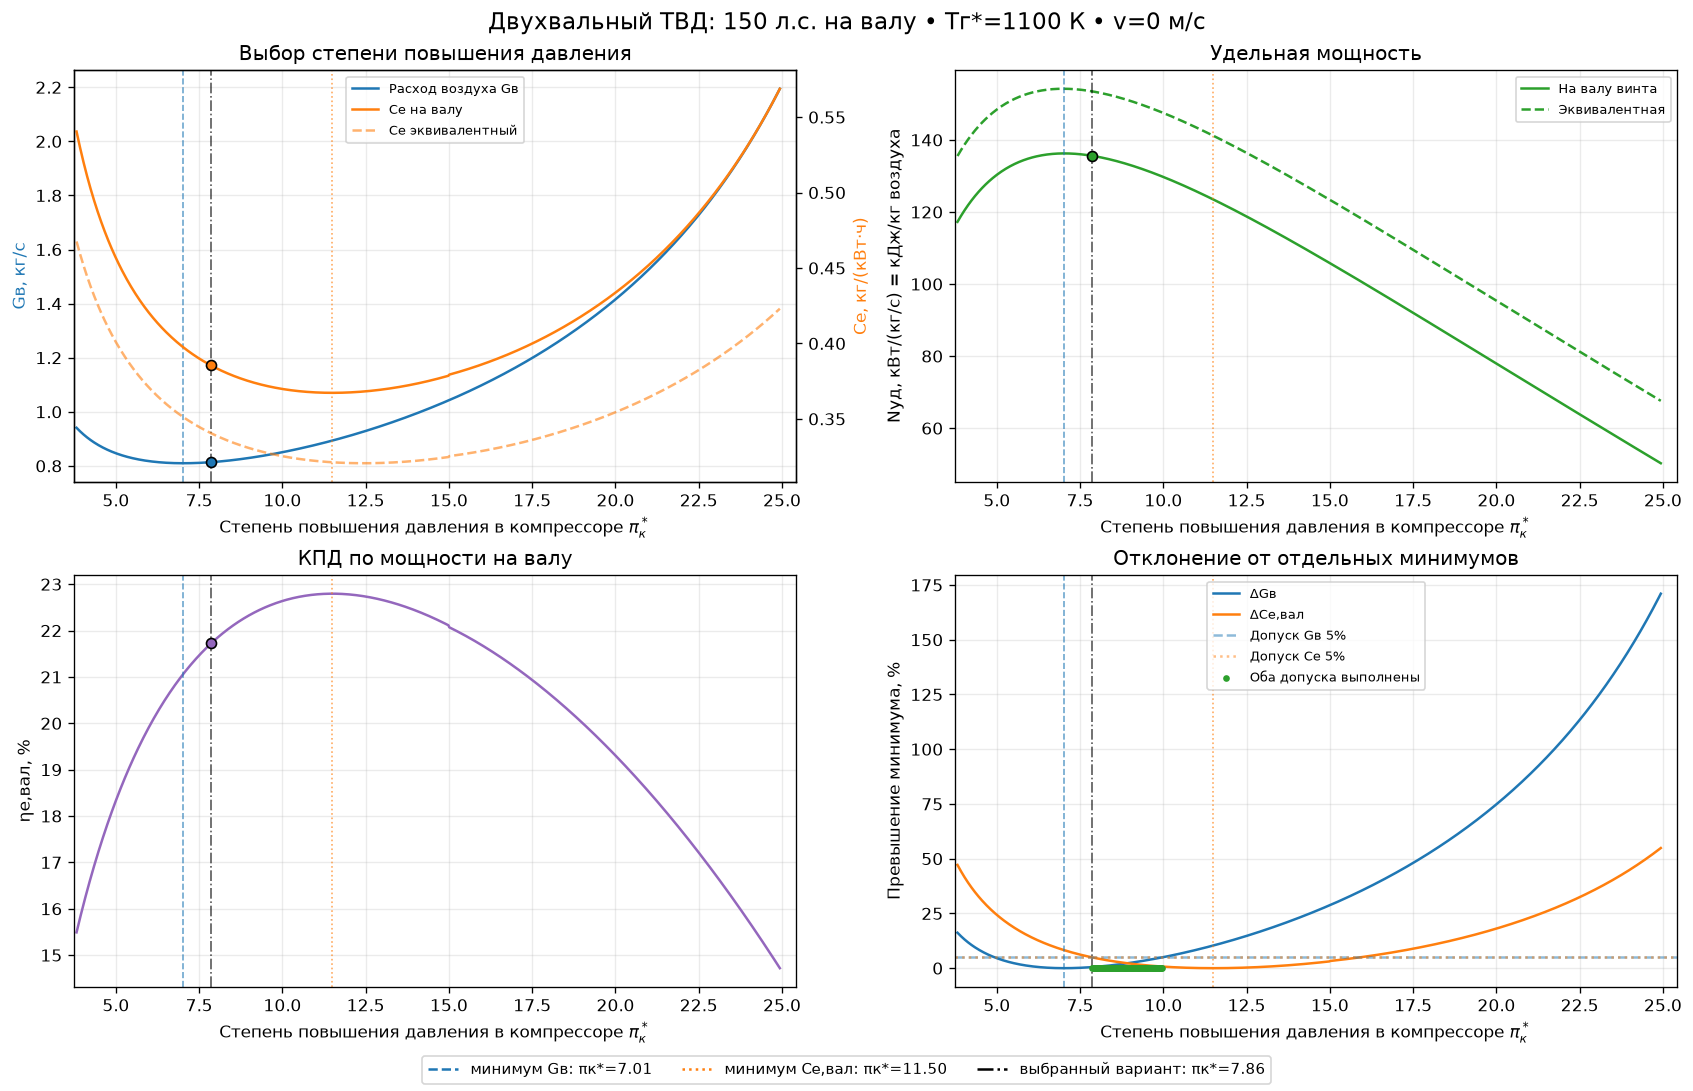

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
x = variants["pi_k"]
markers = [(opt_L["pi_k"], "tab:blue", "--", "минимум Gв"),
           (opt_eta["pi_k"], "tab:orange", ":", "минимум Ce,вал"),
           (s["pi_k"], "black", "-.", "выбранный вариант")]

ax = axes[0, 0]
ax_right = ax.twinx()
line_air, = ax.plot(x, variants["G_air"], color="tab:blue", label="Расход воздуха Gв")
line_fuel, = ax_right.plot(x, variants["Ce_shaft"], color="tab:orange", label="Ce на валу")
line_eq, = ax_right.plot(x, variants["Ce_equiv"], color="tab:orange", linestyle="--", alpha=0.6, label="Ce эквивалентный")
ax.set_ylabel("Gв, кг/с", color="tab:blue")
ax_right.set_ylabel("Ce, кг/(кВт·ч)", color="tab:orange")
ax_right.grid(False)
ax.set_title("Выбор степени повышения давления")
ax.scatter([s["pi_k"]], [s["G_air"]], c="tab:blue", edgecolor="black", zorder=5)
ax_right.scatter([s["pi_k"]], [s["Ce_shaft"]], c="tab:orange", edgecolor="black", zorder=5)
ax.legend(handles=[line_air, line_fuel, line_eq], loc="upper center", fontsize=8)

ax = axes[0, 1]
ax.plot(x, variants["N_specific"], label="На валу винта", color="tab:green")
ax.plot(x, variants["N_equiv_specific"], label="Эквивалентная", color="tab:green", linestyle="--")
ax.scatter([s["pi_k"]], [s["N_specific"]], c="tab:green", edgecolor="black", zorder=5)
ax.set_title("Удельная мощность")
ax.set_ylabel("Nуд, кВт/(кг/с) = кДж/кг воздуха")
ax.legend(fontsize=8)

ax = axes[1, 0]
ax.plot(x, 100*variants["eta_shaft"], color="tab:purple")
ax.scatter([s["pi_k"]], [100*s["eta_shaft"]], c="tab:purple", edgecolor="black", zorder=5)
ax.set_title("КПД по мощности на валу")
ax.set_ylabel("ηe,вал, %")

ax = axes[1, 1]
ax.plot(x, 100*(variants["G_air"]/opt_L["G_air"]-1), label="ΔGв", color="tab:blue")
ax.plot(x, 100*(variants["Ce_shaft"]/opt_eta["Ce_shaft"]-1), label="ΔCe,вал", color="tab:orange")
ax.axhline(100*max_air_penalty, color="tab:blue", alpha=0.5, linestyle="--", label=f"Допуск Gв {100*max_air_penalty:g}%")
ax.axhline(100*max_fuel_penalty, color="tab:orange", alpha=0.5, linestyle=":", label=f"Допуск Ce {100*max_fuel_penalty:g}%")
if not acceptable.empty:
    ax.scatter(acceptable["pi_k"], np.zeros(len(acceptable)), s=9, color="tab:green", label="Оба допуска выполнены", zorder=5)
ax.set_title("Отклонение от отдельных минимумов")
ax.set_ylabel("Превышение минимума, %")
ax.legend(fontsize=8)

for ax in axes.flat:
    for pi, color, style, label in markers:
        ax.axvline(pi, color=color, linestyle=style, alpha=0.65, linewidth=1)
    ax.set_xlabel(r"Степень повышения давления в компрессоре $\pi_к^*$")
    ax.set_xlim(min(pi_low, selected_pi)*0.98, max(pi_high, selected_pi)*1.02)

from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([0], [0], color=c, linestyle=st, label=f"{label}: πк*={pi:.2f}")
                    for pi, c, st, label in markers], loc="outside lower center", ncol=3, fontsize=9)
fig.suptitle(f"Двухвальный ТВД: {P.power_hp:g} л.с. на валу • Tг*={P.T_g:g} К • v={P.velocity:g} м/с", fontsize=14)
plt.show()